In [1]:
%reset -f

In [2]:
from cil.io import ZEISSDataReader
import numpy as np
import os
#current_directory = os.getcwd()
os.chdir('/zhome/71/c/146676/Desktop/msaca/main/')  # Navigate into a subdirectory
#print("Current working directory:", current_directory)
import matplotlib.pyplot as plt
from cil.io import TIFFStackReader
import plotly.graph_objects as go
import plot_library as pl
from scipy.ndimage import rotate
from scipy.interpolate import griddata
import SimpleITK as sitk
import importlib
import registrator
import plotly.io as pio
pio.renderers.default = "notebook"
3+3

6

In [3]:
#reconpath0 = "/home/msaca/Data/sliceB_xray_dtu/sliceB_xray_dtu/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1_recon.txm"
reconpath0 = "/dtu-compute/msaca/sliceB_xray_dtu/sliceB_xray_dtu/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1_recon.txm"


#reconpath_neutron = "/home/msaca/Data/sliceB_neutron_dtu/sliceB_neutron_psi/04_evaluation/fullrecon/"
reconpath_neutron = "/dtu-compute/msaca/sliceB_neutron_dtu/sliceB_neutron_psi/04_evaluation/fullrecon/"

In [4]:
reader = ZEISSDataReader(reconpath0)
recon_xray_ = reader.read()
recon_xray = pl.array_normalizer(recon_xray_.as_array().astype(np.float32))

In [5]:
roi = {'axis_0': (100, 1113, 1)}
reader = TIFFStackReader(reconpath_neutron,roi=roi)
recon_neutron = pl.array_normalizer(reader.read())

In [138]:
importlib.reload(registrator)

<module 'registrator' from '/zhome/71/c/146676/Desktop/msaca/main/registrator.py'>

In [ ]:
reg = registrator.Registrator()
reg.load_images(fixed_array=recon_xray, moving_array=recon_neutron)


In [ ]:
transform_centroid = reg.transformation(type='Centroid')

In [ ]:
reg.resample(transform_centroid)

Resampling the transformation: 220325
Resampling moving image


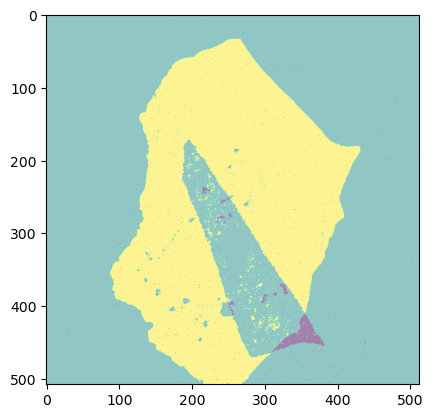

In [ ]:
reg.plot2d(thresholds = [0.20, 0.5],difference=True)

In [ ]:
angle_radians = np.deg2rad(180)
rotation_matrix = [
                [1, 0, 0],
                [0, np.cos(angle_radians), -np.sin(angle_radians)],
                [0, np.sin(angle_radians), np.cos(angle_radians)]
            ]
matrix = [elem for row in rotation_matrix for elem in row]
transform_flip = reg.transformation(type='Similarity3DTransform', matrix=matrix, translation=(0,0,0))


In [ ]:

reg.resample(transform_flip)
#reg.plot2d(thresholds = [0.20, 0.5])


Resampling the transformation: 373934
Resampling moving image


In [ ]:

reg.moving_smooth['2'] = reg.apply_mean(reg.moving, smooth=2)
#reg.moving_smooth['5'] = reg.apply_mean(reg.moving, smooth=5)


In [ ]:
transform_registration = reg.register(learning_rate = [0.1,0.1,0.1], sampling_percentage = [0.5,0.2,0.1], 
                                      convergence_window_size = 120, max_iter = [200,10,40],
                                        metric_type = ['ms', 'ms', 'ms'], optimizer_type = ['gd', 'gd', 'gd'],
                                        inPlace=False, callback = 1,
                                        smoothing = [2,0,0], shrinking = [7],
                                        histogram_bins = 20, thresholds=[0.2, 0.5],
                                        smooth_fixed = False, smooth_moving = True)
reg.resample(transform_registration)


Using precalculated smoothed moving image with shrinking
Using non-smoothed fixed image with shrinking
200
Iteration 0: Metric Value = 0.038055250304970034, Metric Difference = 0.024445530061520934
Iteration 20: Metric Value = 0.032917448650616646, Metric Difference = 0.005137801654353388
Iteration 40: Metric Value = 0.03036098750066735, Metric Difference = 0.0025564611499492955
Iteration 60: Metric Value = 0.024333286471842942, Metric Difference = 0.006027701028824408
Iteration 80: Metric Value = 0.01042327891747683, Metric Difference = 0.013910007554366112
Iteration 100: Metric Value = 0.00807230623452373, Metric Difference = 0.0023509726829531
Iteration 120: Metric Value = 0.013319894838268596, Metric Difference = 0.005247588603744866
Iteration 140: Metric Value = 0.013478722406572365, Metric Difference = 0.0001588275683037689
Iteration 160: Metric Value = 0.013635263710354183, Metric Difference = 0.00015654130378181877
Resampling the transformation: 408917
Resampling moving image
R

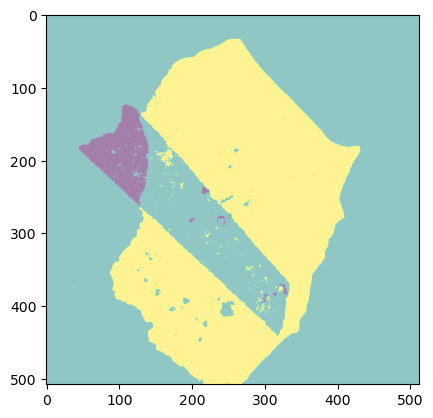

In [137]:
reg.plot2d(thresholds = [0.20, 0.5], difference=True)

In [74]:
transform_registration = reg.register(learning_rate = [0.1], sampling_percentage = [0.1], 
                                      convergence_window_size = 120, max_iter = [100,20],
                                        metric_type = ['ms', 'ms'], optimizer_type = ['gd'],
                                        inPlace=False, callback = 1,
                                        smoothing = [3,0], shrinking = [2],
                                        histogram_bins = 20, thresholds=[0.2, 0.50],
                                        smooth_fixed = False, smooth_moving = True)
reg.resample(transform_registration)

Using precalculated smoothed moving image with shrinking
Using non-smoothed fixed image with shrinking
Iteration 0: Metric Value = 0.03952082280081062, Metric Difference = 0.03436540685750342
Iteration 10: Metric Value = 0.03879611685969377, Metric Difference = 0.0007247059411168502
Iteration 20: Metric Value = 0.03765804882033596, Metric Difference = 0.0011380680393578146
Iteration 30: Metric Value = 0.03649987257605559, Metric Difference = 0.0011581762442803706
Iteration 40: Metric Value = 0.03581501394148145, Metric Difference = 0.0006848586345741398
Iteration 50: Metric Value = 0.03539189774909032, Metric Difference = 0.000423116192391125
Iteration 60: Metric Value = 0.03510298735513182, Metric Difference = 0.0002889103939585011
Iteration 70: Metric Value = 0.03481915690727234, Metric Difference = 0.0002838304478594844
Iteration 80: Metric Value = 0.03457745874877962, Metric Difference = 0.00024169815849271747
Iteration 90: Metric Value = 0.0343229619784906, Metric Difference = 0.0

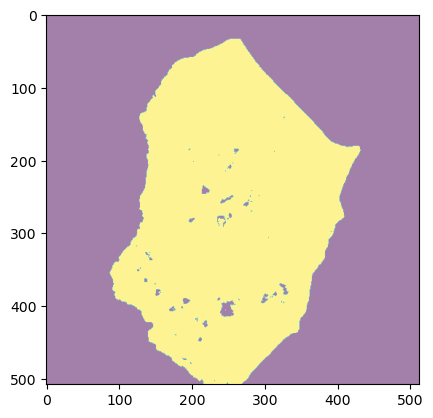

In [75]:
reg.plot2d(thresholds = [0.20, 0.50], difference=True)

In [127]:
transform_registration = reg.register(learning_rate = [0.1], sampling_percentage = [0.1], 
                                      convergence_window_size = 120, max_iter = [20,20],
                                        metric_type = ['mmi', 'ms'], optimizer_type = ['gd'],
                                        inPlace=False, callback = 1,
                                        smoothing = [5,0], shrinking = [2],
                                        histogram_bins = 20, thresholds=[0.2, 0.50])
reg.resample(transform_registration)

Smoothing images
Iteration 0: Metric Value = -0.17546530408666472, Metric Difference = 0.17898231754314958
Iteration 2: Metric Value = -0.17590873770348137, Metric Difference = 0.0004434336168166464
Iteration 4: Metric Value = -0.1760414917114212, Metric Difference = 0.00013275400793982817
Iteration 6: Metric Value = -0.17592846331423637, Metric Difference = 0.00011302839718482782
Iteration 8: Metric Value = -0.17559787565948745, Metric Difference = 0.00033058765474891505
Iteration 10: Metric Value = -0.17529528301816702, Metric Difference = 0.0003025926413204316
Iteration 12: Metric Value = -0.17519528356384775, Metric Difference = 9.999945431926616e-05
Iteration 14: Metric Value = -0.1752012287135064, Metric Difference = 5.945149658653781e-06
Iteration 16: Metric Value = -0.17523130090156633, Metric Difference = 3.0072188059920846e-05
Iteration 18: Metric Value = -0.17526177193856723, Metric Difference = 3.0471037000906476e-05
Resampling the transformation: 47477


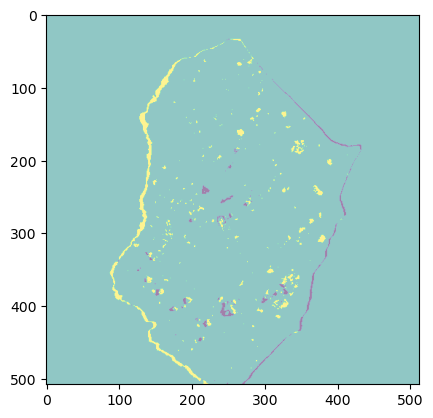

In [128]:
reg.plot2d(thresholds = [0.20, 0.50], difference=True)

Iteration 0: Metric Value = -0.14096053727785107, Metric Difference = 0.03996726508211089
Iteration 10: Metric Value = -0.13686909526776617, Metric Difference = 0.004091442010084906
Iteration 0: Metric Value = -0.07334989130257082, Metric Difference = 0.06351920396519535
Iteration 10: Metric Value = -0.09871200563369481, Metric Difference = 0.025362114331123994
Iteration 0: Metric Value = -0.07963601169806467, Metric Difference = 0.019075993935630142
Iteration 10: Metric Value = -0.10387496812001171, Metric Difference = 0.02423895642194704


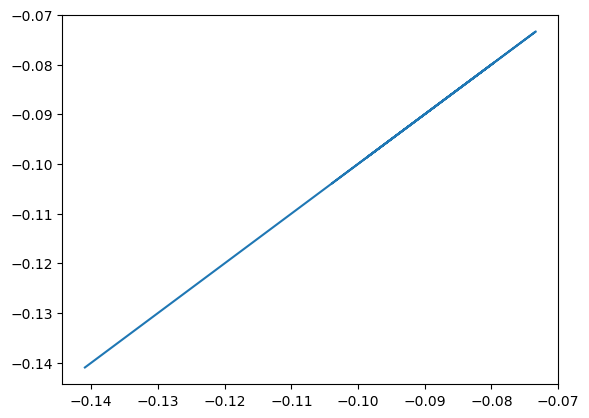

Iteration 0: Metric Value = -0.15976354961997455, Metric Difference = 0.05588858149996284
Iteration 10: Metric Value = -0.17395013345049187, Metric Difference = 0.014186583830517324
Iteration 0: Metric Value = -0.10242838707603504, Metric Difference = 0.07152174637445684
Iteration 10: Metric Value = -0.12485969340806138, Metric Difference = 0.02243130633202635
Iteration 0: Metric Value = -0.10195956058891782, Metric Difference = 0.022900132819143562
Iteration 10: Metric Value = -0.09976329607384721, Metric Difference = 0.0021962645150706145


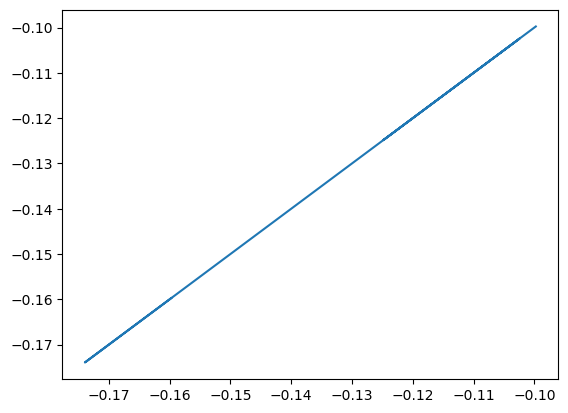

In [77]:

transform_registration2 = reg.register(learning_rate=0.01, max_iter = 100, convergence_window_size=20, callback=True)
reg.resample(transform_registration2)

transform_registration3 = reg.register(learning_rate=0.001, max_iter = 100, convergence_window_size=20,sampling_percentage = 0.3, callback=True)
reg.resample(transform_registration3)

In [104]:
# Align principal axes with coordinate axes
out = reg.compute_principal_moments_and_axes([0.5,0.5])
matrix = out['fixed']['axes'].T.flatten()
transform_coordinate_axes = reg.transformation(type='Euler3DTransform',matrix=matrix)

In [105]:
total_transform = sitk.CompositeTransform([transform_centroid, transform_flip, transform_registration,transform_coordinate_axes])
transform_fixed = reg.transformation(type='Euler3DTransform',matrix=matrix)

reg.resample(transform_fixed, fixed=True)
reg.resample(transform_fixed)

reg_downsized.resample(total_transform)
reg_downsized.resample(transform_fixed, fixed=True)

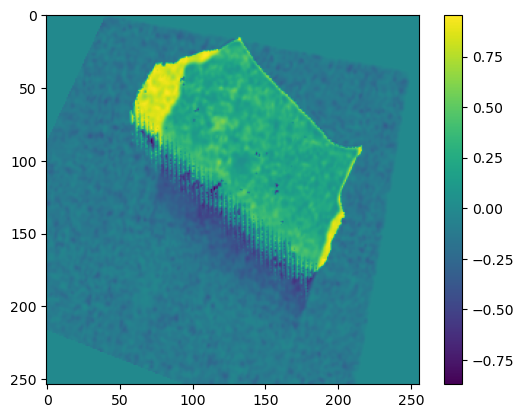

In [108]:
p1 = sitk.GetArrayFromImage(reg.fixed)[:,:,130]
p2 = sitk.GetArrayFromImage(reg.moving)[:,:,130]
plt.imshow(p1-p2)
plt.colorbar()
plt.show()

In [106]:
#reg_full.resample(total_transform)
#reg_full.resample(transform_fixed, fixed=True)
#reg_downsized.resample(total_transform)
#reg_downsized.resample(transform_fixed, fixed=True)
#reg_full_binary.resample(total_transform)
#reg_full_binary.resample(transform_fixed, fixed=True)
g1 = sitk.GradientMagnitude(reg.fixed)
g2 = sitk.GradientMagnitude(reg.moving)
reg_g = registrator.Registrator()
reg_g.fixed = g1
reg_g.moving = g2

transform_registration4 = reg_g.register(learning_rate=0.01, max_iter = 200, convergence_window_size=10,sampling_percentage = 0.3)
out_m = reg_g.resample(transform_registration4,inplace=False)

out_m = sitk.GetArrayFromImage(out_m)
out_f = sitk.GetArrayFromImage(reg_g.fixed)

out_o_m = reg.resample(transform_registration4,inplace=False)
out_o_f = reg.fixed


print(np.sum(np.abs(out_o_m - out_o_f)))

N = 127
plt.imshow(out_m[:,:,N])
plt.show()
plt.imshow(out_f[:,:,N])
plt.show()
plt.imshow(out_m[:,:,N] - out_f[:,:,N])

KeyboardInterrupt: 

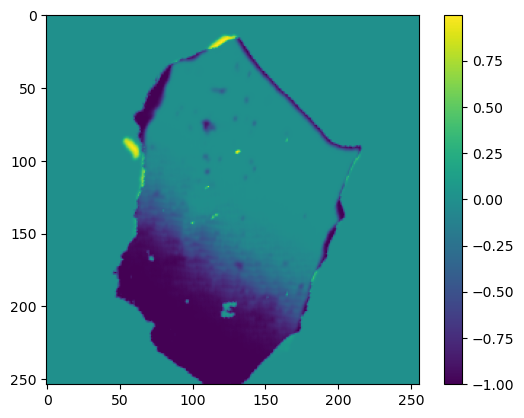

9789.732


In [131]:
N = 125
plt.imshow(sitk.GetArrayFromImage(reg.moving)[:,:,N]-sitk.GetArrayFromImage(reg.fixed)[:,:,N])
plt.colorbar()
plt.show()
print(np.sum(np.abs(sitk.GetArrayFromImage(reg.moving)[:,:,N]-sitk.GetArrayFromImage(reg.fixed)[:,:,N])))

In [116]:
sitk.GetArrayFromImage(reg.fixed)[90:110,:,N]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [63]:
out = reg.compute_principal_moments_and_axes([0.5,0.5])
print(out)

{'fixed': {'moment': (570.9885747004955, 20895.169937989645, 46117.68197396244), 'axes': array([[ 0.31020022,  0.86229604,  0.40027662],
       [-0.93442417,  0.35406451, -0.03859791],
       [-0.17500657, -0.36205507,  0.91558114]]), 'centroid': array([-20.36630191,   3.81297805,  35.80012499])}, 'moving': {'moment': (719.6364810214181, 23263.84684720545, 49149.331975942754), 'axes': array([[ 0.31271486,  0.86711709,  0.38770783],
       [-0.93193344,  0.35899332, -0.05122364],
       [-0.18360142, -0.3452995 ,  0.92035796]]), 'centroid': array([-19.70363846,  -4.22766203,  32.90036749])}}


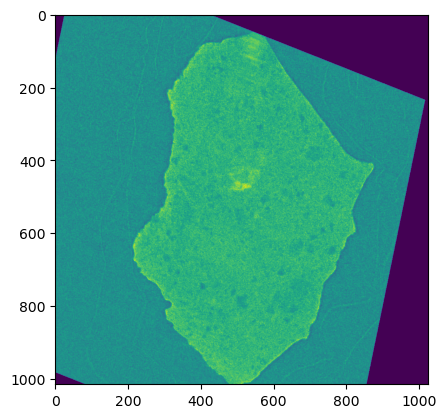

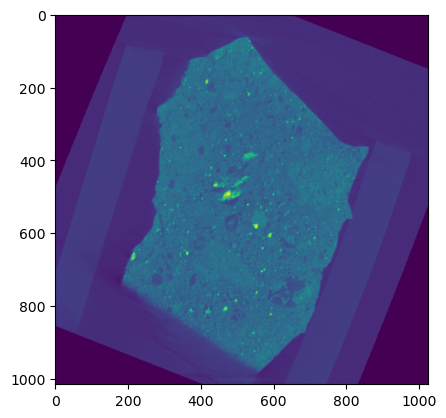

In [64]:
N = 475
plt.imshow(sitk.GetArrayFromImage(reg_full.moving)[:,:,N])
plt.show()
plt.imshow(sitk.GetArrayFromImage(reg_full.fixed)[:,:,N])
plt.show()


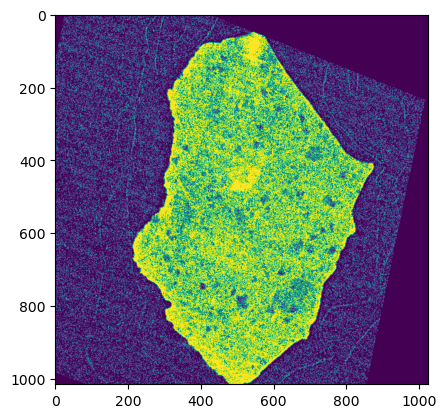

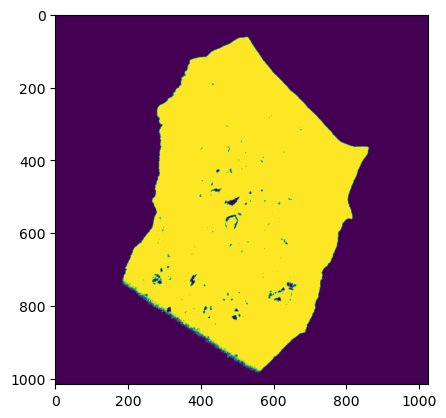

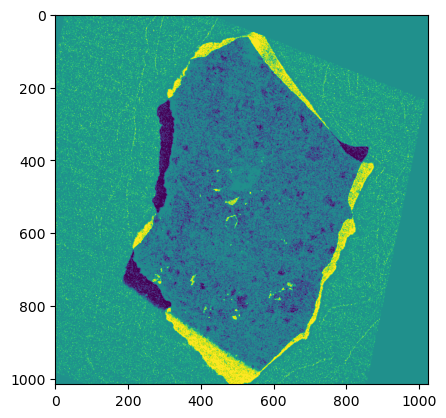

In [65]:
plt.imshow(sitk.GetArrayFromImage(reg_full_binary.moving)[:,:,N])
plt.show()
plt.imshow(sitk.GetArrayFromImage(reg_full_binary.fixed)[:,:,N])
plt.show()

diff = sitk.GetArrayFromImage(reg_full_binary.moving) - sitk.GetArrayFromImage(reg_full_binary.fixed)
plt.imshow(diff[:,:,N])
plt.show()

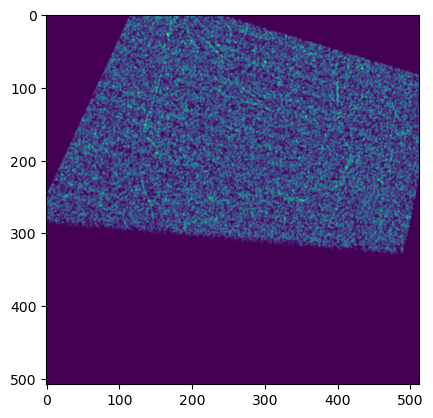

In [27]:
diff = sitk.GetArrayFromImage(reg.moving) - sitk.GetArrayFromImage(reg.fixed)
plt.imshow(diff[:,:,163])

In [80]:
plt.imshow(sitk.GetArrayFromImage(reg_downsized.moving)[50])
plt.show()
plt.imshow(sitk.GetArrayFromImage(reg_downsized.fixed)[50])
plt.show()

In [81]:
print(np.shape(sitk.GetArrayFromImage(reg.moving)))
plt.imshow(sitk.GetArrayFromImage(reg.moving)[30])
plt.show()
plt.imshow(sitk.GetArrayFromImage(reg.fixed)[30])
plt.show()

In [82]:
recons = Registrator(fixed_data=recon_xray, moving_data=recon_neutron)
recons.downsize(final_size_target = 100 ,fixed_or_moving = 'fixed')
recons.downsize(final_size_target = 100 ,fixed_or_moving = 'moving')
print('Downsizing finished')
#recons.thresholder(threshold = 0.2, fixed_or_moving = 'fixed', downsized = False)
recons.thresholder(threshold = 0.2, fixed_or_moving = 'fixed', downsized = True)

#recons.thresholder(threshold = 0.5, fixed_or_moving = 'moving', downsized = False)
recons.thresholder(threshold = 0.5, fixed_or_moving = 'moving', downsized = True)

In [ ]:
recons.set_main(downsized = True, mask = True)
recons.transform_initial()
matrix = (0.8160936658664071, -0.28856459951138586, 0.02374979627874302, 0.2766920759330827, 0.7563278026519324, -0.31820151230511134, 0.08529405624244589, 0.3074754937003145, 0.8050007435556675)
translation = (15.245151809618564, 15.175912405966365, -20.850352829049456)
scale = 1.0 #0.8652125177637796
recons.apply_similarity_transform(matrix,translation,scale)
angle_degrees = 180
recons.rotate_about_yz_plane(angle_degrees,axis='x')

In [ ]:
#recons.SetupRegistration()
#recons.ExecuteRegistration()
#params = recons.get_transformation_parameters()
evals, evecs = recons.compute_principal_moments_and_axes()
principal1 = recons.get_largest_eigenvector(evals, evecs, rank = 1)
principal2 = recons.get_largest_eigenvector(evals, evecs, rank = 2)
centroid = recons.get_centroid()
print(principal1)
print(principal2)
print(centroid)
recons.create_mirroring_transform([0,0,0]], principal1, principal2)

In [ ]:
# Code: 
# Matrix: (0.8160936658664071, -0.28856459951138586, 0.02374979627874302, 0.2766920759330827, 0.7563278026519324, -0.31820151230511134, 0.08529405624244589, 0.3074754937003145, 0.8050007435556675)
# Versor:(0.18667249795024038, -0.01836190339688423, 0.16864592205798945, 0.9676645968443155)
# Translation: (15.245151809618564, 15.175912405966365, -20.850352829049456)
# Scale: 0.8652125177637796
# Center: (0.0, 0.0, 0.0)
#pars = recons.registration_transform.GetNthTransform(0).GetScale()
#print(pars)

In [360]:
#recons.resample()
#recons.resample
moved = recons.convert_to_array(recons.adjust)
fixed = recons.fixed_d_mask

for slice_ in range(20):
    slice = slice_*5
    plt.imshow(moved[slice] - fixed[slice])
    plt.clim([-1,1])
    plt.show()
    #plt.imshow(moved[slice])
    #plt.show()
    #plt.imshow(fixed[slice])
    #plt.show()

print(np.sum(moved**2))
print(np.sum(fixed**2))
print(np.sum(np.abs(fixed-moved)))

In [ ]:

for slice_ in range(20):
    slice = slice_*5
    plt.imshow(moved[slice] - fixed[slice])
    plt.clim([-1,1])
    plt.show()
    #plt.imshow(moved[slice])
    #plt.show()
    #plt.imshow(fixed[slice])
    #plt.show()

print(np.sum(moved**2))
print(np.sum(fixed**2))
print(np.sum(fixed-moved)**2)